In [1]:
import numpy as np
import json
import torch
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is available!
Number of GPUs: 1
Current GPU Name: NVIDIA GeForce RTX 3060
CUDA Version used by PyTorch: 12.6


Пути к каталогам.

In [3]:
config_dir = Path("./config/")
dataset_dir = Path('./zeros-poles-dataset/')
dataset_noisy_dir = Path('./zeros-poles-dataset-noisy/')

Загрузка файла конфигурации.

In [4]:
config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    configer = json.load(f)

Проверка генерации масок.

In [5]:
from utils.general_functions import generate_masks

masks = generate_masks(masks={}, configer=configer)
mask_dict = masks["1zp2lp1rp2lz0rz_001"]
print(mask_dict)

{'zero_poles': 1, 'left_poles': [152, 71], 'right_poles': [142], 'left_zeros': [477, 272], 'right_zeros': []}


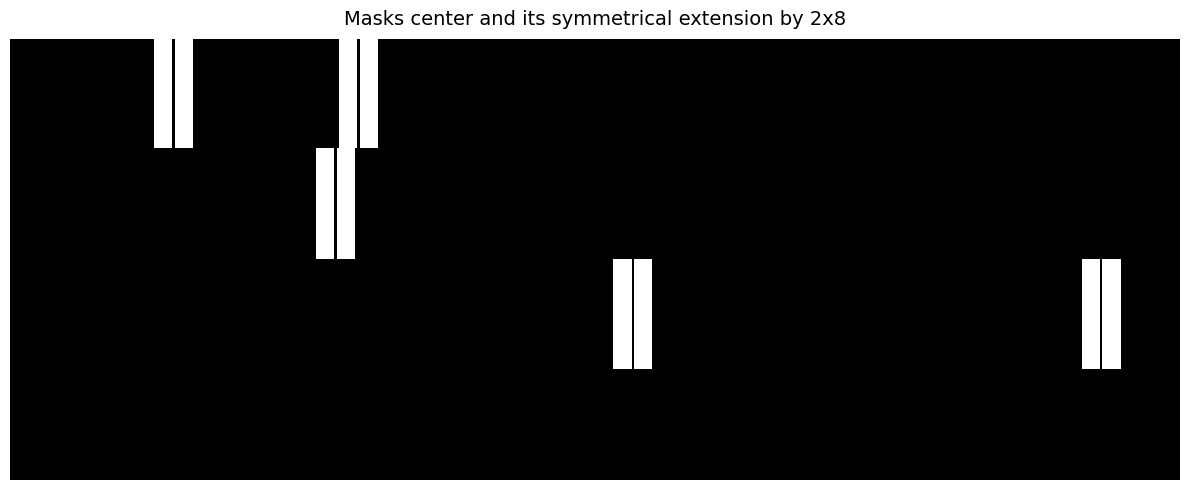

In [6]:
from utils.ZerosPolesDataset import positions_to_mask

halfwindow_list = [0, 8]

# Collect differences in a single loop
diff_masks = []

for key, positions in mask_dict.items():
    if key == 'zero_poles':
        continue
    mask = []
    for hw in halfwindow_list:
        mask.append(
            positions_to_mask(
                positions=positions,
                total_bits=configer['length'],
                halfwindow=hw
            )
        )

    diff = np.abs(np.array(mask[0], dtype=int) - np.array(mask[-1], dtype=int))
    diff_masks.append(diff)

plt.figure(figsize=(12, 5))
plt.imshow(diff_masks, cmap='gray', aspect='auto', interpolation='nearest')
plt.title(f'Masks center and its symmetrical extension by 2x{halfwindow_list[1]}', fontsize=14, pad=10)
plt.axis('off')
plt.tight_layout()
plt.show()

# Пример работы с dataloader

In [7]:
import secrets
SEED = configer.get('seed', None)# secrets.randbelow(2**32)
if SEED:
    torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

In [8]:
from utils.ZerosPolesDataset import ZerosPolesDataset, TransformsConfig, GeneralTransforms, ConversionTransforms

N_samples = 4
split = 'debug'
sample_type = None#'0zp2lp1rp0lz0rz'

if sample_type is None:
    # Read all masks.
    mask_path = Path(dataset_dir) / (split + "_masks.json")
    assert mask_path.exists(), f"Mask not found: {mask_path}"
    with open(mask_path, "r") as f:
        masks = json.load(f)
    # Полный перечень ключей.    
    samples_full = list(masks.keys())
    samples = rng.choice(samples_full, size=N_samples, replace=False).tolist()
else:
    # Generate mask names for the sample_type specified.
    samples = []
    for _ in range(N_samples):
        samples.append(f'{sample_type}_{rng.integers(0, 100):03d}')

## Последовательно создаем и визуализируем несколько датасетов

In [9]:
from utils.plot_functions import plot_responses

PLOT_CONFIG = {
    'fontsize': 14,
    'fontsize_legend': 10,
    'fig_width': 8,
    'fig_height_per_row': 2,
    'max_samples_to_plot': 12,
    'markersize_data': 3,
    'markersize_mask': 10,
    'grid_alpha': 0.5,
    'plots': [
        {
            'ylabel': 'Magnitude, dB',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'mag'
        },
        {
            'ylabel': 'Phase, deg',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'ph'
        },
        {
            'ylabel': 'Diff 1 (Mag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff1_mag'
        },
        {
            'ylabel': 'Diff 1 (Phase)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff1_ph'
        },
        {
            'ylabel': 'Diff 2 (Mag)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff2_mag'
        },
        {
            'ylabel': 'Diff 2 (Phase)',
            'xlabel': 'Samples',
            'xscale': 'linear',
            'arg_key': 'samples',
            'data_key': 'diff2_ph'
        }
    ],
    'masks': [
        {'label': 'left_pole',  'color': '#e377c2', 'marker': 'o'},
        {'label': 'right_pole', 'color': '#d62728', 'marker': 'p'},
        {'label': 'left_zero',  'color': '#bcbd22', 'marker': 's'},
        {'label': 'right_zero', 'color': '#ff7f0e', 'marker': '^'},
    ]
}

### Датасет чистый, но с аугментациями

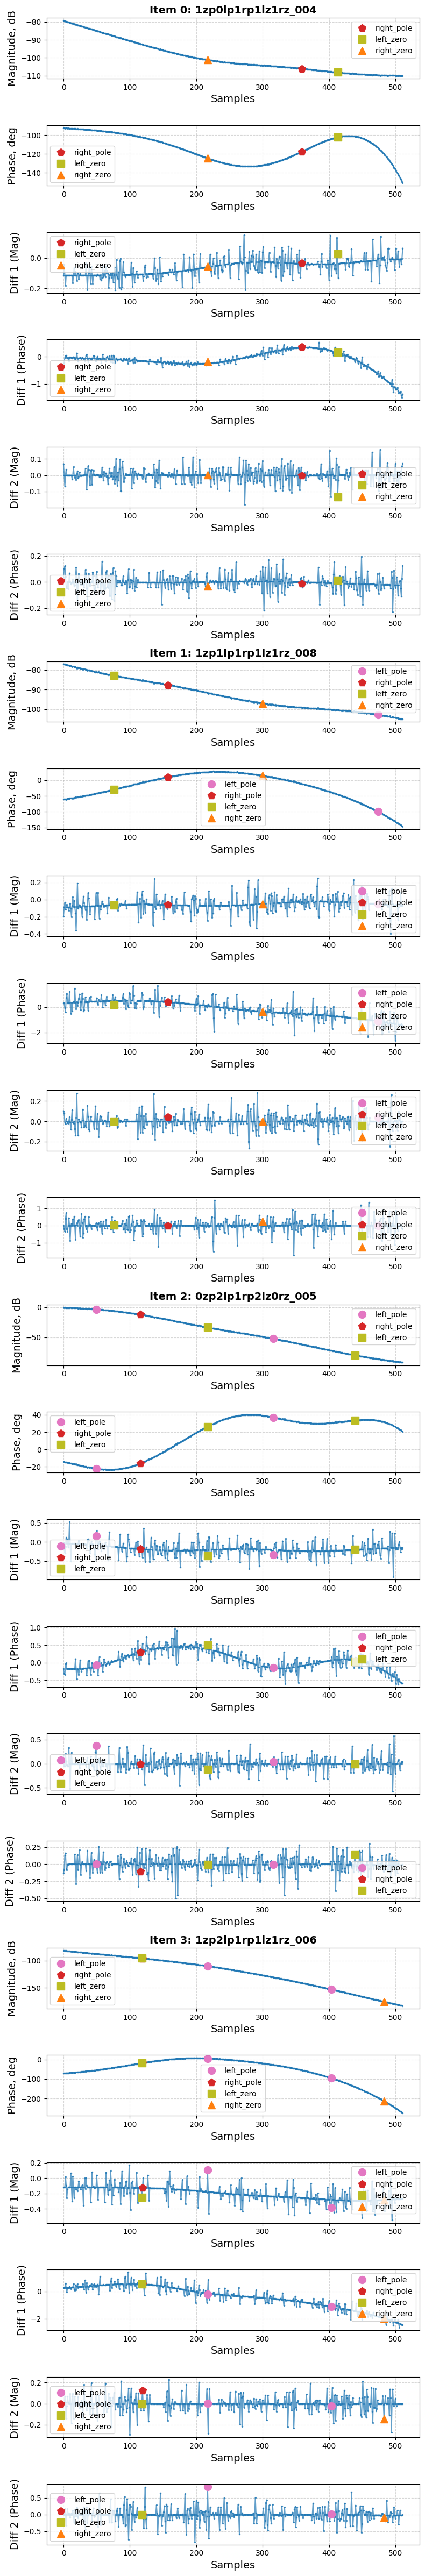

In [10]:
transforms_general_conversion = [
    GeneralTransforms(
        config=TransformsConfig(
            phase_delay=[0.0, np.pi],
            noise_level=[5e-3, 30e-3],
            noise_reduce=2)
        ),
    ConversionTransforms(
        num_iter=2,
        return_input=True
        )]

dataset_general_conversion = ZerosPolesDataset(
    dataset_dir=dataset_dir,
    split=split,
    mask_halfwindow=0,
    samples=samples,
    transforms=transforms_general_conversion
)

plot_responses(
    dataset_to_plot=dataset_general_conversion,
    samples_list=samples,
    N_plot_samples=N_samples,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/augmented_dataset_samples.png'))

### Датасет чистый, нет аугментаций

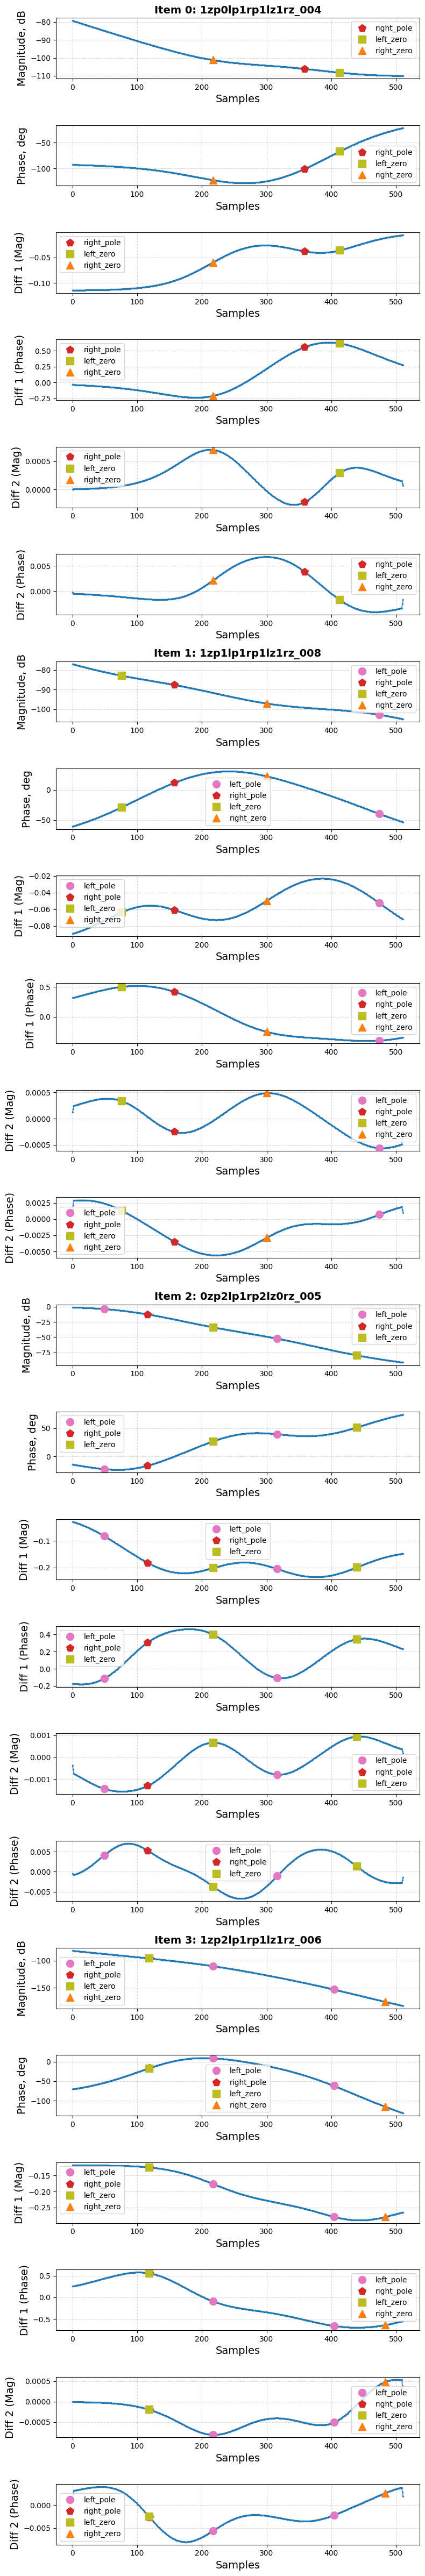

In [11]:
transforms_conversion_only = [
    ConversionTransforms(
        num_iter=2,
        return_input=True
        )]

dataset_conversion_only = ZerosPolesDataset(
    dataset_dir=dataset_dir,
    split=split,
    mask_halfwindow=0,
    samples=samples,
    transforms=transforms_conversion_only
)

plot_responses(
    dataset_to_plot=dataset_conversion_only,
    samples_list=samples,
    N_plot_samples=N_samples,
    plot_config=PLOT_CONFIG,
    save_path=Path('./readme_img/dataset_samples.png'))

### Датасет шумный изначально, нет аугментаций

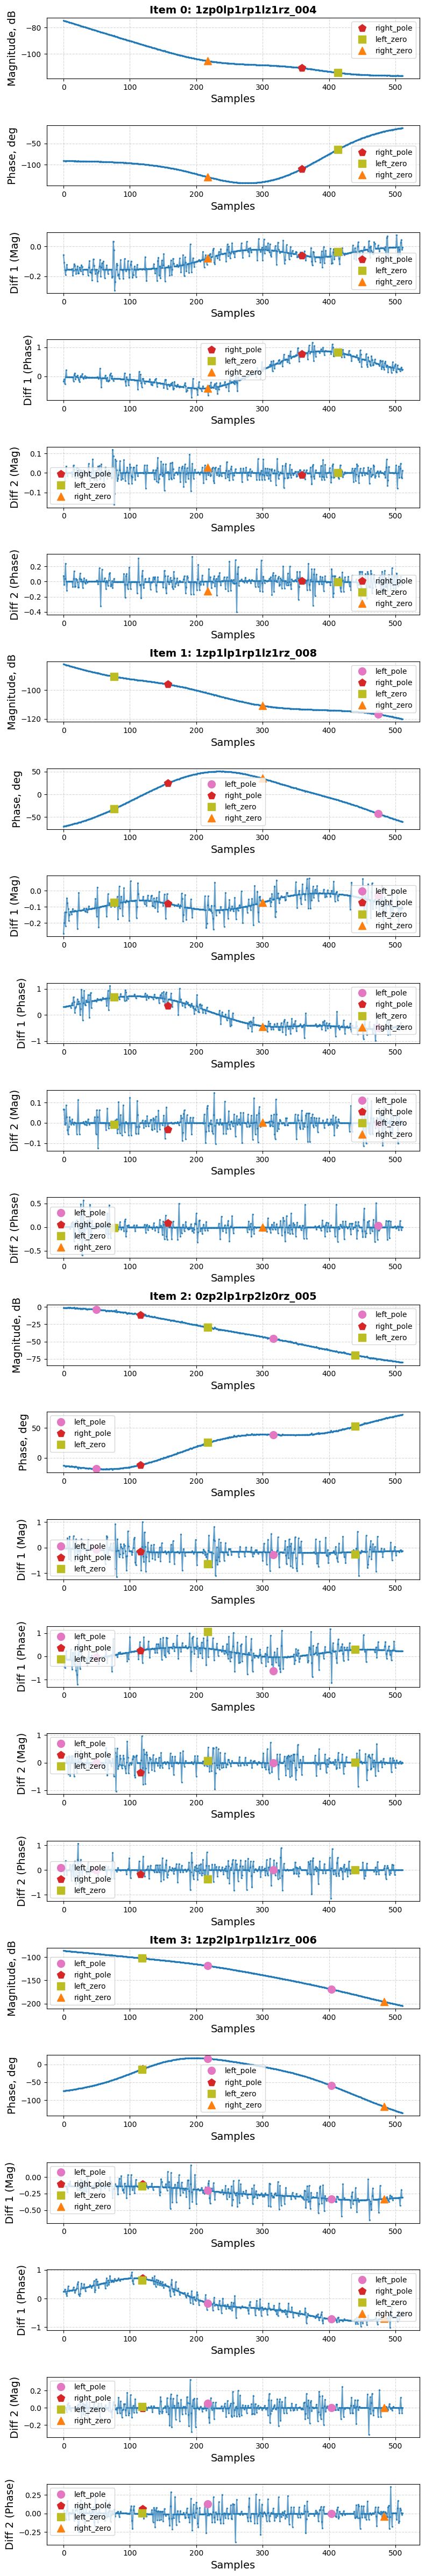

In [12]:
dataset_noisy = ZerosPolesDataset(
    dataset_dir=dataset_noisy_dir,
    split=split,
    mask_halfwindow=0,
    samples=samples,
    transforms=transforms_conversion_only
)

plot_responses(
    dataset_to_plot=dataset_noisy,
    samples_list=samples,
    N_plot_samples=N_samples,
    plot_config=PLOT_CONFIG,
    save_path=None)